# Victim clasificator
Script backend para construir y evaluar el clasificador de víctima.<br>
Junta todas las celdas de código en una.<br>
Construye la tabla con datos, el conjunto de entrenamiento y validación.<br>
Entrena el modelo Decission Tree, lo evalua y muestra los resultados de la evaluación como resultado final.<br>

### Pre-condición
Tu gráfica puede ayudarte con el cálculo, comprúebalo ejecutando el código de aqui abajo👇

In [1]:
#%pip install torch torchvision torchaudio
import torch

print(torch.cuda.is_available())

False


### Ejecución
El siguiente código realiza el proceso de clasificación explicado al comienzo.

Dim características:  (4024, 29)
Dim target:  (4024, 11)
Valores faltantes:  0
['VÍCTIMA', 'PERPETRADOR', 'VICTIMA_PERPETRADOR', 'POLIVICTIMIZACION', 'POLIPERPETRACION', 'SOLO.VICTIMA', 'SOLO.PERPETRADOR', 'NO.VICT_NO.PERP', 'V.O', 'P.SUM.TOTAL', 'V.SUM.TOTAL']


,PAÍS,ETNIA.BN,EDAD,FUGAS.BN,ABUSOSUBS1,ABUSOSUBS2,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4,...,APOYO.MEAN,APOYO.MEDIAN,APOYO.VAR,MORAL.MEAN,MORAL.VAR,PORNO.T,GENERO.BN0,ORIENTSEX.BN0,GENERO.BN1,ORIENTSEX.BN1
0,True,False,16.0,False,4,4,1.0,1.0,0.0,0.0,...,4.000000,4.0,0.000000,5.0,0.00,1.0,False,True,True,False
1,True,False,16.0,False,3,2,1.0,1.0,0.0,0.0,...,3.428571,4.0,0.530612,2.8,0.56,4.0,True,True,False,False
2,True,False,17.0,False,3,3,1.0,1.0,0.0,0.0,...,3.285714,4.0,0.775510,4.2,0.96,3.0,False,True,True,False
3,True,False,16.0,False,3,3,1.0,1.0,0.0,0.0,...,3.285714,4.0,0.775510,4.0,0.40,4.0,True,True,False,False
4,True,False,17.0,False,3,3,1.0,1.0,0.0,0.0,...,3.571429,4.0,0.530612,4.4,1.44,2.0,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3762,True,False,14.0,False,0,0,1.0,1.0,0.0,0.0,...,3.285714,4.0,1.061224,3.6,0.24,1.0,False,True,True,False
3763,False,False,14.0,True,2,0,1.0,1.0,0.0,0.0,...,2.714286,3.0,1.061224,4.4,0.64,1.0,False,True,True,False
3764,True,False,14.0,False,2,0,1.0,1.0,0.0,0.0,...,3.714286,4.0,0.489796,4.8,0.16,1.0,False,True,True,False
3765,False,False,14.0,False,0,0,1.0,1.0,0.0,0.0,...,3.714286,4.0,0.204082,5.0,0.00,1.0,False,True,True,False


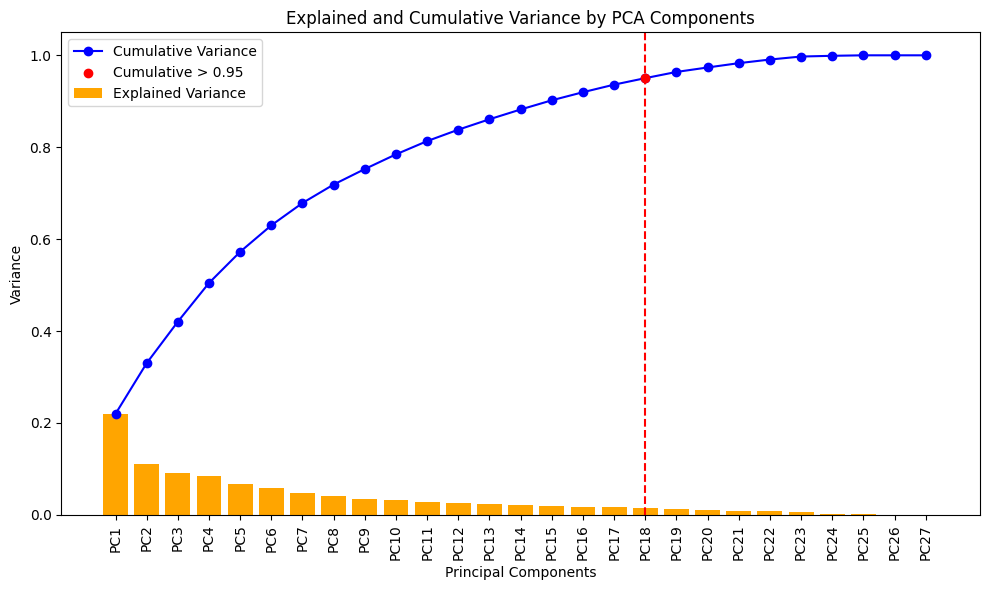

,PC,var_1,loading_1,var_2,loading_2,var_3,loading_3,var_4,loading_4,var_5,loading_5
0,PC1,GENERO.BN1,0.661206,GENERO.BN0,-0.661206,PORNO.T,-0.284534,ORIENTSEX.BN0,-0.125540,ORIENTSEX.BN1,0.125540
1,PC2,CONVIVEN_H,0.637478,CONVIVEN.2,0.546152,ETNIA.BN,-0.214185,ORIENTSEX.BN1,-0.203226,ORIENTSEX.BN0,0.203226
2,PC3,ORIENTSEX.BN0,0.617373,ORIENTSEX.BN1,-0.617373,CONVIVEN_H,-0.257547,CONVIVEN.2,-0.184961,PORNO.T,-0.178758
3,PC4,CONVIVEN_H,0.615232,ETNIA.BN,0.591395,CONVIVEN.2,-0.291896,PAÍS,-0.289786,CONVIVEN.3,0.135615
4,PC5,EDAD,0.454275,ABUSOSUBS1,0.449741,CONVIVEN.2,-0.309139,FUGAS.BN,0.305471,CONVIVEN_H,0.300263
5,PC6,CONVIVEN.2,0.589144,ETNIA.BN,0.454111,FUGAS.BN,0.329730,EDAD,0.257767,CONVIVEN.3,-0.250112
6,PC7,FUGAS.BN,0.537957,EDAD,-0.511682,APOYO.MEDIAN,-0.342069,APOYO.MEAN,-0.286716,APOYO.VAR,0.283990
7,PC8,APOYO.MEDIAN,0.460418,FUGAS.BN,0.457336,EDAD,-0.398378,APOYO.MEAN,0.384896,APOYO.VAR,-0.381690
8,PC9,CONVIVEN_0,0.858626,CONVIVEN.1,-0.375257,FUGAS.BN,-0.183131,CONVIVEN.2,0.140779,ETNIA.BN,-0.134353
9,PC10,PORNO.T,0.741074,FUGAS.BN,-0.369642,EDAD,-0.364454,ABUSOSUBS1,0.181917,CONVIVEN_0,-0.171125


CSV SMART AND guardado en: content/victim/predictions_with_probs.csv
Mejor ccp_alpha: 0.01441
Recall final categoría 1 (Víctima): 0.9054
Recall final categoría 0 (No Víctima): 0.2474
CSV de probabilidades guardado en: ./DT_victim/predictions_with_probabilities.csv
Artefactos generados en carpeta './DT_victim':
 - train_vs_cv_recall_1.png
 - test_recall_vs_ccp_alpha_1.png
 - pruned_tree.png
 - tree_rules.txt
 - pruned_clf.joblib
              precision    recall  f1-score   support

         0.0       0.73      0.25      0.37       477
         1.0       0.54      0.91      0.68       465

    accuracy                           0.57       942
   macro avg       0.63      0.58      0.52       942
weighted avg       0.64      0.57      0.52       942



In [4]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path
import re
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import recall_score
from collections import Counter
from sklearn.metrics import classification_report

def perform_pca(df: pd.DataFrame,
                save_scaler_path: str = "models/scaler_minmax.pkl",
                save_pca_path: str = "models/modelo_pca.pkl",
                save_means_path: str = "models/medias_escalado.csv"
               ):
    """
    Realiza un PCA sobre el DataFrame de entrada y devuelve:
      1) df_pca: DataFrame con las componentes principales (PC1, PC2, …).
      2) df_var: DataFrame con las varianzas explicada y acumulada por componente.
      3) scaler: MinMaxScaler ya entrenado.
      4) pca: PCA ya entrenado.
      5) means: Series con la media de cada variable tras escalado.
    Además guarda automáticamente el scaler, el modelo PCA y el vector de medias en rutas predeterminadas.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame numérico de entrada (n muestras × p variables).
    save_scaler_path : str
        Ruta por defecto donde volcar el scaler (pickle).
    save_pca_path : str
        Ruta por defecto donde volcar el modelo PCA (pickle).
    save_means_path : str
        Ruta por defecto donde guardar las medias de cada variable tras escalado (CSV).

    Retorna
    -------
    df_pca : pd.DataFrame
        Transformación PCA (n muestras × p componentes), columnas PC1…PCp.
    df_var : pd.DataFrame
        Tabla con columnas:
          - PC: nombre de la componente ("PC1", "PC2", …)
          - explained variance: varianza explicada por cada componente
          - cumulative variance: varianza acumulada hasta esa componente
    scaler : MinMaxScaler
        Objeto scaler ajustado (fit).
    pca : PCA
        Objeto PCA ajustado (fit).
    means : pd.Series
        Media de cada variable tras el escalado (para centrar nuevos datos).
    """
    # Crear carpetas si no existen

    os.makedirs(os.path.dirname(save_scaler_path), exist_ok=True)
    os.makedirs(os.path.dirname(save_pca_path), exist_ok=True)
    os.makedirs(os.path.dirname(save_means_path), exist_ok=True)

    # 1) Escalado al rango [0,1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler.fit_transform(df.values)

    # 2) Cálculo de medias para centrar
    means_array = X_scaled.mean(axis=0)
    means = pd.Series(means_array, index=df.columns, name='mean')

    # 3) Centramos cada variable usando las medias calculadas
    X_centered = X_scaled - means_array

    # 4) Ajustar y transformar PCA
    pca = PCA(n_components=df.shape[1])
    comps = pca.fit_transform(X_centered)

    # 5) DataFrame de componentes principales
    cols = [f"PC{i+1}" for i in range(df.shape[1])]
    df_pca = pd.DataFrame(comps, index=df.index, columns=cols)

    # 6) Varianzas explicada y acumulada
    var_ratio = pca.explained_variance_ratio_
    cum_var  = var_ratio.cumsum()
    df_var = pd.DataFrame({
        "PC": cols,
        "explained variance": var_ratio,
        "cumulative variance": cum_var
    })

    # 7) Guardar a disco en rutas por defecto
    joblib.dump(scaler, save_scaler_path)
    joblib.dump(pca, save_pca_path)
    means.to_csv(save_means_path, header=True)

    return df_pca, df_var, scaler, pca, means

def plot_pca_variance(df_var):
    """
    Genera un barplot de la varianza explicada (barras amarillas) y un lineplot
    de la varianza acumulada (línea azul), marcando con un punto rojo donde
    la varianza acumulada supera el 0.95.

    Parámetros
    ----------
    df_var : pandas.DataFrame
        DataFrame con columnas:
          - "PC": nombres de componentes ("PC1", "PC2", …)
          - "explained variance": varianza explicada por componente
          - "cumulative variance": varianza acumulada
    """
    # Preparar datos
    x = range(len(df_var))
    explained = df_var['explained variance']
    cumulative = df_var['cumulative variance']

    # Crear la figura
    plt.figure(figsize=(10, 6))

    # Barplot de varianza explicada
    plt.bar(x, explained, color='orange', label='Explained Variance')

    # Lineplot de varianza acumulada
    plt.plot(x, cumulative, color='blue', marker='o', label='Cumulative Variance')

    # Punto rojo donde cumulative > 0.95
    above_idx = df_var.index[cumulative > 0.95]
    if not above_idx.empty:
        idx0 = above_idx[0]
        plt.scatter(idx0, cumulative[idx0], color='red', zorder=5, label='Cumulative > 0.95')
        plt.axvline(x=idx0, color='red', linestyle='--')

    # Configuración de ejes y leyenda
    plt.xticks(x, df_var['PC'], rotation=90)
    plt.xlabel('Principal Components')
    plt.ylabel('Variance')
    plt.title('Explained and Cumulative Variance by PCA Components')
    plt.legend()
    plt.tight_layout()
    plt.show()


def select_PCA_df(df_var: pd.DataFrame, df_PCA: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """
    Selecciona las primeras i componentes principales de df_PCA donde i es el número de componente
    tal que el primer valor de 'cumulative variance' en df_var supera el umbral dado.

    Args:
        df_var (pd.DataFrame): DataFrame con columnas 'PC' (etiquetas 'PC1', 'PC2', ...) y
                               'cumulative variance' (float entre 0 y 1).
        df_PCA (pd.DataFrame): DataFrame resultante de una PCA, con tantas columnas como componentes.
        threshold (float): Umbral de varianza acumulada entre 0 y 1.

    Returns:
        pd.DataFrame: Subset de df_PCA con las primeras i columnas.
    """
    # Validación de umbral
    if not (0 <= threshold <= 1):
        raise ValueError("El umbral debe estar entre 0 y 1")

    # Buscar el primer índice que supere el threshold
    mask = df_var['cumulative variance'] > threshold
    if not mask.any():
        raise ValueError("Ningún valor de varianza acumulada supera el umbral dado")

    idx = mask.idxmax()  # índice del primer True
    pc_label = df_var.loc[idx, 'PC']  # p.ej. 'PC3'

    # Extraer i del string 'PCi'
    match = re.match(r'PC(\d+)', pc_label)
    if not match:
        raise ValueError(f"Formato inesperado en etiqueta PC: {pc_label}")
    i = int(match.group(1))

    # Seleccionar las primeras i columnas de df_PCA
    return df_PCA.iloc[:, :i]

def DT_victim_classifier(df_pca: pd.DataFrame,
                         df_target: pd.Series,
                         output_dir: str = "victim_classifier"):
    """
    Entrena un DecisionTreeClassifier para la detección de víctimas, explora overfitting,
    aplica cost-complexity pruning, y guarda artefactos (gráficas, csv, reglas, modelo).

    Además genera un CSV con las probabilidades de la clase predicha para cada muestra del test,
    incluyendo el índice original, el valor real, el valor predicho y la probabilidad.

    Parámetros
    ----------
    df_pca : pd.DataFrame
        DataFrame con las 16 componentes PCA.
    df_target : pd.Series
        Serie con la etiqueta binaria 'VÍCTIMA' (0/1).
    output_dir : str
        Ruta donde se guardarán todos los artefactos generados.

    Retorna
    -------
    pruned_clf : DecisionTreeClassifier
        Clasificador podado con el mejor ccp_alpha.
    best_alpha : float
        Valor de ccp_alpha seleccionado.
    recall_1_final : float
        Recall en la categoría 1 (víctima) sobre el set de test.
    recall_0_final : float
        Recall en la categoría 0 (no víctima) sobre el set de test.
    """
    # Crear carpeta de salida si no existe
    os.makedirs(output_dir, exist_ok=True)

    # 1. División estratificada sobre índices para conservar el ori_idx
    idx_train, idx_test = train_test_split(
        df_pca.index,
        test_size=0.25,
        random_state=42,
        stratify=df_target
    )
    X_train_df = df_pca.loc[idx_train]
    X_test_df  = df_pca.loc[idx_test]
    y_train_s  = df_target.loc[idx_train]
    y_test_s   = df_target.loc[idx_test]

    # Guardar CSV de splits
    X_train_df.to_csv(os.path.join(output_dir, "X_train.csv"), index=True)
    X_test_df .to_csv(os.path.join(output_dir, "X_test.csv"),  index=True)
    y_train_s.to_csv(os.path.join(output_dir, "y_train.csv"), index=True)
    y_test_s .to_csv(os.path.join(output_dir, "y_test.csv"),  index=True)

    # Convertir a arrays para sklearn
    X_train = X_train_df.values
    X_test  = X_test_df.values
    y_train = y_train_s.values
    y_test  = y_test_s.values
    feature_names = df_pca.columns.tolist()

    # 2. Exploración de overfitting variando max_depth
    depths = list(range(1, 21))
    train_recall = []
    cv_recall    = []
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, random_state=42)
        clf.fit(X_train, y_train)
        train_recall.append(recall_score(y_train, clf.predict(X_train), pos_label=1))
        cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='recall')
        cv_recall.append(np.mean(cv_scores))

    plt.figure()
    plt.plot(depths, train_recall, label='Train Recall (1)')
    plt.plot(depths, cv_recall,    label='CV Recall (1)')
    plt.xlabel('max_depth')
    plt.ylabel('Recall categoría 1')
    plt.title('Train vs CV Recall(1) según max_depth')
    plt.legend()
    plt.savefig(os.path.join(output_dir, "train_vs_cv_recall_1.png"), dpi=300)
    plt.close()

    # 3. Árbol completo y cost_complexity_pruning_path
    full_clf = DecisionTreeClassifier(random_state=42)
    full_clf.fit(X_train, y_train)
    path = full_clf.cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas

    # 4. Evaluación recall(1) en test según cada alpha
    test_recall_1 = []
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        test_recall_1.append(recall_score(y_test, clf.predict(X_test), pos_label=1))

    plt.figure()
    plt.plot(ccp_alphas, test_recall_1, marker='o', drawstyle="steps-post")
    plt.xscale('log')
    plt.xlabel('ccp_alpha')
    plt.ylabel('Test Recall categoría 1')
    plt.title('Test Recall(1) vs ccp_alpha (poda)')
    plt.savefig(os.path.join(output_dir, "test_recall_vs_ccp_alpha_1.png"), dpi=300)
    plt.close()

    # 5. Selección del mejor alpha y cálculo de recalls finales
    best_idx      = np.argmax(test_recall_1)
    best_alpha    = ccp_alphas[best_idx]
    pruned_clf    = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    pruned_clf.fit(X_train, y_train)

    # 6. Predicciones y probabilidades en el set de test
    y_pred      = pruned_clf.predict(X_test)
    y_proba_all = pruned_clf.predict_proba(X_test)

    # Probabilidad de la clase positiva (VÍCTIMA = 1), no la probabilidad de la clase predicha.
    classes = list(pruned_clf.classes_)
    if 1 in classes:
        class1_pos = classes.index(1)
    else:
        raise ValueError(f"No se encuentra la clase positiva 1 en pruned_clf.classes_: {pruned_clf.classes_}")

    y_prob_class1 = y_proba_all[:, class1_pos]

    # Probabilidad de la clase predicha: se conserva solo como trazabilidad/debug.
    y_pred_int = y_pred.astype(int)
    proba_pred = [probs[classes.index(pred_int)] for probs, pred_int in zip(y_proba_all, y_pred_int)]

    # 7. Construcción y guardado del DataFrame de resultados histórico
    df_results = pd.DataFrame({
        "ori_idx": idx_test,
        "real_value": y_test,
        "predicted_value": y_pred,
        "probability_predicted_class": proba_pred,
        "probability_class1": y_prob_class1
    })
    csv_path = os.path.join(output_dir, "predictions_with_probabilities.csv")
    df_results.to_csv(csv_path, index=False)

    # 7b. CSV estándar para el cuaderno SMART AND
    smart_dir = Path("./content/victim")
    smart_dir.mkdir(parents=True, exist_ok=True)
    df_smart = pd.DataFrame({
        "idx_original": idx_test,
        "y_true_victim": y_test.astype(int),
        "y_pred_victim": y_pred.astype(int),
        "y_prob_victim": y_prob_class1
    })
    smart_csv_path = smart_dir / "predictions_with_probs.csv"
    df_smart.to_csv(smart_csv_path, index=False)
    print(f"CSV SMART AND guardado en: {smart_csv_path}")

    # 8. Métricas finales
    recall_1_final = recall_score(y_test, y_pred, pos_label=1)
    recall_0_final = recall_score(y_test, y_pred, pos_label=0)
    print(f"Mejor ccp_alpha: {best_alpha:.5f}")
    print(f"Recall final categoría 1 (Víctima): {recall_1_final:.4f}")
    print(f"Recall final categoría 0 (No Víctima): {recall_0_final:.4f}")
    print(f"CSV de probabilidades guardado en: {csv_path}")

    # 9. Visualización del árbol podado
    plt.figure(figsize=(20, 10))
    plot_tree(
        pruned_clf,
        filled=True,
        feature_names=feature_names,
        class_names=['No Víctima', 'Víctima'],
        rounded=True
    )
    plt.title(f"Árbol podado (ccp_alpha={best_alpha:.5f})")
    plt.savefig(os.path.join(output_dir, "pruned_tree.png"), dpi=300)
    plt.close()

    # 10. Exportar reglas del árbol a txt
    rules = export_text(pruned_clf, feature_names=feature_names)
    with open(os.path.join(output_dir, "tree_rules.txt"), 'w') as f:
        f.write(rules)

    # 11. Guardar el modelo podado
    joblib.dump(pruned_clf, os.path.join(output_dir, "pruned_clf.joblib"))

    print(f"Artefactos generados en carpeta '{output_dir}':")
    print(" - train_vs_cv_recall_1.png")
    print(" - test_recall_vs_ccp_alpha_1.png")
    print(" - pruned_tree.png")
    print(" - tree_rules.txt")
    print(" - pruned_clf.joblib")

    return pruned_clf, best_alpha, recall_1_final, recall_0_final, X_test_df, y_test_s, y_pred, y_prob_class1, idx_test

def get_DT_rules(scaler_path: str,
                 pca_path: str,
                 means_csv_path: str,
                 feat_cols_csv_path: str,
                 tree_rules_path: str,
                 output_csv_path: str) -> pd.DataFrame:
    """
    Extrae las reglas del árbol de decisión podado y las convierte en
    hiperplanos en el espacio original de features.

    Parámetros
    ----------
    scaler_path : str
        Ruta al MinMaxScaler serializado (joblib .pkl).
    pca_path : str
        Ruta al modelo PCA serializado (joblib .pkl).
    means_csv_path : str
        Ruta al CSV con las medias de los features escalados.
    feat_cols_csv_path : str
        Ruta al CSV cuyo header contiene los nombres de las variables originales.
    tree_rules_path : str
        Ruta al TXT con las reglas exportadas por export_text().
    output_csv_path : str
        Ruta donde guardar el DataFrame resultante (CSV).

    Retorna
    -------
    df_reglas : pd.DataFrame
        DataFrame con cada regla expresada como β·x + constante y el target asignado.
    """
    # 1) Cargar modelos y parámetros
    scaler   = joblib.load(scaler_path)
    pca       = joblib.load(pca_path)
    means_df  = pd.read_csv(means_csv_path, index_col=0)
    feat_cols = pd.read_csv(feat_cols_csv_path, index_col=0).columns.tolist()

    # convertir 'means' a array
    if "mean" in means_df.columns:
        means_array = means_df["mean"].values
    else:
        means_array = means_df.squeeze().values

    s    = scaler.scale_     # 1/(max-min)
    dmin = scaler.data_min_  # mínimos crudos

    # 2) Leer y parsear todo el árbol
    tree_nodes = []
    with open(tree_rules_path, "r") as f:
        for line in f:
            indent = line.count("|   ")
            # nodo de split?
            m = re.search(r"\|---\s*(PC\d+)\s*(<=|>)\s*([-\d.]+)", line)
            if m:
                pc, op, thr = m.groups()
                tree_nodes.append({"type":"split","indent":indent,
                                   "pc":pc,"op":op,"thr":float(thr)})
                continue
            # nodo hoja?
            m2 = re.search(r"\|---\s*class:\s*([01])", line)
            if m2:
                tree_nodes.append({"type":"leaf","indent":indent,
                                   "target":int(m2.group(1))})

    # 3) Asignar a cada split el target mayoritario de sus hojas hijas
    reglas = []
    for idx, node in enumerate(tree_nodes):
        if node["type"] != "split":
            continue
        indent0 = node["indent"]
        targets = []
        for sub in tree_nodes[idx+1:]:
            if sub["indent"] <= indent0:
                break
            if sub["type"] == "leaf":
                targets.append(sub["target"])
        target = Counter(targets).most_common(1)[0][0] if targets else None
        reglas.append((node["pc"], node["op"], node["thr"], target))

    # 4) Construir filas con β y constante en el espacio original
    filas = []
    for pc_name, operador, umbral, target in reglas:
        idx_pc     = int(pc_name[2:]) - 1
        w          = pca.components_[idx_pc]
        beta       = w * s
        base       = np.dot(w, s * dmin + means_array)

        if operador == "<=":
            const     = umbral + base
            beta_rule = beta
        else:  # ">"
            const     = -umbral - base
            beta_rule = -beta

        fila = {
            "pc":        pc_name,
            "operador":  operador,
            "umbral":    umbral,
            "constante": const,
            "target":    target
        }
        for feat, b in zip(feat_cols, beta_rule):
            fila[f"β_{feat}"] = b
        filas.append(fila)

    # 5) DataFrame final, guardado y retorno
    df_reglas = pd.DataFrame(filas)
    df_reglas.to_csv(output_csv_path, index=False)
    return df_reglas

feat_df = pd.read_csv('./data/lista_global_vars.csv')
target_df = pd.read_csv('./data/target_col.csv').fillna(0) # fillna imputa los missings con la categoría 0 que es la correcta.

print("Dim características: ",feat_df.shape)
print("Dim target: ",target_df.shape)
print("Valores faltantes: ", feat_df.isna().sum().sum()+target_df.isna().sum().sum())
print(target_df.columns.to_list())

#procedo a juntar target y feature antes de eliminar un par de categorías muy desbalanceadas y sus registros asociados.
df_merged = feat_df.join(target_df, how='inner')
df_merged = df_merged[~((df_merged["GENERO_BIN_2"] == 1) | (df_merged["ORIENTSEX.BN_3"] == 1))].drop(columns=["GENERO_BIN_2","ORIENTSEX.BN_3"]).reset_index(drop=True)

#procedo a juntar target y feature antes de eliminar un par de categorías muy desbalanceadas y sus registros asociados.
df_merged_victima = df_merged.drop(columns=['PERPETRADOR', 'VICTIMA_PERPETRADOR', 'POLIVICTIMIZACION', 'POLIPERPETRACION', 'SOLO.VICTIMA', 'SOLO.PERPETRADOR', 'NO.VICT_NO.PERP', 'V.O', 'P.SUM.TOTAL', 'V.SUM.TOTAL'])

#Quitamos el warning de replace
pd.set_option('future.no_silent_downcasting', True)
#Limpiamos el data-set
df_merged_victima_feat = df_merged_victima.drop(columns=["VÍCTIMA"])
df_merged_victima_target = df_merged_victima["VÍCTIMA"]
#Pasamos País a Booleano
df_merged_victima_feat['PAÍS'] = df_merged_victima_feat['PAÍS'].replace({1: True, 2: False})
#Pasamos Etnia a Booleano
df_merged_victima_feat['ETNIA.BN'] = df_merged_victima_feat['ETNIA.BN'].replace({0.0: False, 1.0: True})
#Pasamos Fugas a Booleano
df_merged_victima_feat['FUGAS.BN'] = df_merged_victima_feat['FUGAS.BN'].replace({0.0: False, 1.0: True})
#One-hot encoding de Porno
#df_merged_victima_feat = pd.get_dummies(df_merged_victima_feat, columns=['PORNO.T'])

"""
# Variable nueva ABUSOSUBSBINGE
df_merged_victima_feat["ABUSOSUBSBINGE"] = (df_merged_victima_feat["ABUSOSUBS2"] > 0)
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["ABUSOSUBS1"])
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["ABUSOSUBS2"])
"""

"""
# Variable nueva PORNOBINGE
df_merged_victima_feat["PORNOBINGE"] = (df_merged_victima_feat["PORNO.T"] > 5)
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["PORNO.T"])
"""

"""
#Limpiamos genero y orientacion sexual
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["GENERO_BIN_1","ORIENTSEX.BN_2"])
#Renombramos
df_merged_victima_feat = df_merged_victima_feat.rename(columns=
                                                       {'GENERO_BIN_0': 'GENERO.BN', 'ORIENTSEX.BN_1': 'ORIENTSEX.BN'})
#Convertimos a booleano
df_merged_victima_feat['GENERO.BN'] = df_merged_victima_feat['GENERO.BN'].replace({0.0: False, 1.0: True})
df_merged_victima_feat['ORIENTSEX.BN'] = df_merged_victima_feat['ORIENTSEX.BN'].replace({0.0: False, 1.0: True})
"""

#Alternativa, convertimos a booleanos sin limpiar para no perder precisión
df_merged_victima_feat['GENERO.BN0'] = df_merged_victima_feat['GENERO_BIN_0'].replace({0.0: False, 1.0: True})
df_merged_victima_feat['ORIENTSEX.BN0'] = df_merged_victima_feat['ORIENTSEX.BN_1'].replace({0.0: False, 1.0: True})
df_merged_victima_feat['GENERO.BN1'] = df_merged_victima_feat['GENERO_BIN_1'].replace({0.0: False, 1.0: True})
df_merged_victima_feat['ORIENTSEX.BN1'] = df_merged_victima_feat['ORIENTSEX.BN_2'].replace({0.0: False, 1.0: True})
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["GENERO_BIN_0","GENERO_BIN_1","ORIENTSEX.BN_1","ORIENTSEX.BN_2"])

#Convive con hermanos
df_merged_victima_feat = df_merged_victima_feat.rename(columns= {'CONVIVEN.5': 'CONVIVEN_H'})
df_merged_victima_feat['CONVIVEN_H'] = df_merged_victima_feat['CONVIVEN_H'].replace({0.0: False, 1.0: True})
#Conviven con 0 progenitores
df_merged_victima_feat = df_merged_victima_feat.rename(columns= {'CONVIVEN.6': 'CONVIVEN_0'})
df_merged_victima_feat['CONVIVEN_0'] = df_merged_victima_feat['CONVIVEN_0'].replace({0.0: False, 1.0: True})
"""
#Conviven con 1 progenitore
df_merged_victima_feat['CONVIVEN_1'] = ((df_merged_victima_feat[['CONVIVEN.1','CONVIVEN.2','CONVIVEN.3','CONVIVEN.4']] == 1).sum(axis=1) == 1)
#Conviven con 2 progenitores
df_merged_victima_feat['CONVIVEN_2'] = ((df_merged_victima_feat[['CONVIVEN.1','CONVIVEN.2','CONVIVEN.3','CONVIVEN.4']] == 1).sum(axis=1) > 1)
#Limpiamos las conviven viejas
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["CONVIVEN.1","CONVIVEN.2","CONVIVEN.3","CONVIVEN.4"])

#Conviven con progenitores
df_merged_victima_feat["CONVIVEN_P"] = (df_merged_victima_feat["CONVIVEN.1"] > 0 ) | (df_merged_victima_feat["CONVIVEN.2"] > 0) | (df_merged_victima_feat["CONVIVEN.3"] > 0) | (df_merged_victima_feat["CONVIVEN.4"] > 0)
df_merged_victima_feat = df_merged_victima_feat.drop(columns=["CONVIVEN_0","CONVIVEN.1","CONVIVEN.2","CONVIVEN.3","CONVIVEN.4"])
"""
#Mostramos el data-set final
display(df_merged_victima_feat)

#Guardamos los data-set
df_merged_victima_feat.to_csv("df_victima_feat.csv")
df_merged_victima_target.to_csv("df_victima_target.csv")
#Hacemos PCA
df_pca, df_variance, scaler, pca, means = perform_pca(df_merged_victima_feat)
plot_pca_variance(df_variance)

#Mostramos las max_variables variables más importantes de cada PC hasta max_PC
max_PC = 18
max_variables = 5
loadings = pd.DataFrame(
    pca.components_,
    columns=df_merged_victima_feat.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
filas = []
for pc in loadings.index[:max_PC]:
    s = loadings.loc[pc].sort_values(key=abs, ascending=False).head(max_variables)

    fila = {"PC": pc}

    for i, (var, valor) in enumerate(s.items(), start=1):
        fila[f"var_{i}"] = var
        fila[f"loading_{i}"] = valor

    filas.append(fila)
tabla_top_pcs = pd.DataFrame(filas)
display(tabla_top_pcs)

#Corremos el clasificador
df_pca_16 = select_PCA_df(df_variance, df_pca, 0.95)
df_variance.to_csv("df_PCA_variance.csv")
df_pca_16.to_csv("df_PCA_95.csv")

#Guardamos los resultados para poderlos evaluar
best_model, best_alpha, recall_1, recall_0, X_test_df, y_test_s, y_pred, y_prob_victim, idx_test = DT_victim_classifier(
    df_pca=df_pca_16,
    df_target=df_merged_victima_target,
    output_dir="./DT_victim"
)

# Alias para mantener compatibilidad con celdas antiguas que usaban pruned_clf
pruned_clf = best_model
df_rules = get_DT_rules(
    scaler_path="./models/scaler_minmax.pkl",
    pca_path="./models/modelo_pca.pkl",
    means_csv_path="./models/medias_escalado.csv",
    feat_cols_csv_path="./df_victima_feat.csv",
    tree_rules_path="./DT_victim/tree_rules.txt",
    output_csv_path="./DT_victim/hyperplane_rules_with_target.csv"
)

#Evaluamos los resultados
data_set = pd.read_csv('./DT_victim/predictions_with_probabilities.csv')
true_column = data_set['real_value']
pred_column = data_set['predicted_value']

print(classification_report(true_column, pred_column))


### Exploración de los datos

In [5]:
feat_df = pd.read_csv('./data/lista_global_vars.csv')
display(feat_df.head())
display(feat_df[(feat_df["ABUSOSUBS1"] == 0 ) & (feat_df["ABUSOSUBS2"] > 0)])
feat_df["ABUSOSUBSBINGE"] = (feat_df["ABUSOSUBS1"] > 0 ) & (feat_df["ABUSOSUBS2"] > 0)
display(feat_df[["ABUSOSUBS1","ABUSOSUBS2","ABUSOSUBSBINGE"]])

#Conviven con 1 o más progenitores
feat_df["CONVIVEN_P"] = (feat_df["CONVIVEN.1"] > 0 ) | (feat_df["CONVIVEN.2"] > 0) | (feat_df["CONVIVEN.3"] > 0) | (feat_df["CONVIVEN.4"] > 0)
display(feat_df[["CONVIVEN_P","CONVIVEN.1","CONVIVEN.2","CONVIVEN.3","CONVIVEN.4"]])
feat_df_filt = feat_df[feat_df["CONVIVEN_P"] == False]
display(feat_df_filt[["CONVIVEN_P","CONVIVEN.1","CONVIVEN.2","CONVIVEN.3","CONVIVEN.4"]])

,PAÍS,ETNIA.BN,EDAD,FUGAS.BN,ABUSOSUBS1,ABUSOSUBS2,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4,...,APOYO.VAR,MORAL.MEAN,MORAL.VAR,PORNO.T,GENERO_BIN_0,GENERO_BIN_1,GENERO_BIN_2,ORIENTSEX.BN_1,ORIENTSEX.BN_2,ORIENTSEX.BN_3
0,1,0.0,16.0,0.0,4,4,1.0,1.0,0.0,0.0,...,0.000000,5.0,0.00,1.0,0,1,0,1,0,0
1,1,0.0,16.0,0.0,3,2,1.0,1.0,0.0,0.0,...,0.530612,2.8,0.56,4.0,1,0,0,1,0,0
2,1,0.0,17.0,0.0,3,3,1.0,1.0,0.0,0.0,...,0.775510,4.2,0.96,3.0,0,1,0,1,0,0
3,1,0.0,16.0,0.0,3,3,1.0,1.0,0.0,0.0,...,0.775510,4.0,0.40,4.0,1,0,0,1,0,0
4,1,0.0,17.0,0.0,3,3,1.0,1.0,0.0,0.0,...,0.530612,4.4,1.44,2.0,0,1,0,1,0,0


,PAÍS,ETNIA.BN,EDAD,FUGAS.BN,ABUSOSUBS1,ABUSOSUBS2,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4,...,APOYO.VAR,MORAL.MEAN,MORAL.VAR,PORNO.T,GENERO_BIN_0,GENERO_BIN_1,GENERO_BIN_2,ORIENTSEX.BN_1,ORIENTSEX.BN_2,ORIENTSEX.BN_3
6,1,0.0,16.0,0.0,0,1,1.0,1.0,0.0,0.0,...,0.204082,3.8572,0.195967,2.0,1,0,0,0,1,0
20,2,1.0,17.0,0.0,0,1,1.0,1.0,0.0,0.0,...,0.122449,4.0000,0.400000,1.0,1,0,0,1,0,0
21,1,0.0,17.0,0.0,0,1,1.0,1.0,0.0,0.0,...,0.244898,4.6000,0.240000,1.0,1,0,0,1,0,0
22,1,1.0,17.0,0.0,0,1,1.0,1.0,0.0,0.0,...,0.000000,4.2000,1.360000,1.0,0,1,0,1,0,0
25,1,0.0,17.0,0.0,0,1,1.0,0.0,0.0,1.0,...,0.122449,4.0000,0.400000,2.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3842,1,0.0,15.0,1.0,0,1,1.0,1.0,0.0,0.0,...,0.489796,4.6000,0.240000,5.0,1,0,0,1,0,0
3843,1,0.0,15.0,0.0,0,1,1.0,1.0,0.0,0.0,...,0.244898,4.4000,0.240000,1.0,0,1,0,0,1,0
3844,1,0.0,15.0,0.0,0,1,1.0,1.0,1.0,1.0,...,1.142857,3.6000,1.440000,4.0,1,0,0,0,0,1
3845,1,0.0,15.0,1.0,0,1,1.0,1.0,0.0,0.0,...,1.265306,3.4000,1.840000,5.0,1,0,0,1,0,0


,ABUSOSUBS1,ABUSOSUBS2,ABUSOSUBSBINGE
0,4,4,True
1,3,2,True
2,3,3,True
3,3,3,True
4,3,3,True
...,...,...,...
4019,0,0,False
4020,2,0,False
4021,2,0,False
4022,0,0,False


,CONVIVEN_P,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4
0,True,1.0,1.0,0.0,0.0
1,True,1.0,1.0,0.0,0.0
2,True,1.0,1.0,0.0,0.0
3,True,1.0,1.0,0.0,0.0
4,True,1.0,1.0,0.0,0.0
...,...,...,...,...,...
4019,True,1.0,1.0,0.0,0.0
4020,True,1.0,1.0,0.0,0.0
4021,True,1.0,1.0,0.0,0.0
4022,True,1.0,1.0,0.0,0.0


,CONVIVEN_P,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4
19,False,0.0,0.0,0.0,0.0
54,False,0.0,0.0,0.0,0.0
62,False,0.0,0.0,0.0,0.0
130,False,0.0,0.0,0.0,0.0
146,False,0.0,0.0,0.0,0.0
...,...,...,...,...,...
3785,False,0.0,0.0,0.0,0.0
3860,False,0.0,0.0,0.0,0.0
3888,False,0.0,0.0,0.0,0.0
3908,False,0.0,0.0,0.0,0.0


In [6]:
# Guardar/rehacer el CSV estándar para SMART AND usando el best_model y la probabilidad de clase 1
# Ejecuta esta celda DESPUÉS de la celda principal de entrenamiento.

import pandas as pd
import numpy as np
from pathlib import Path

required_vars = ["best_model", "X_test_df", "y_test_s", "y_pred", "idx_test"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Faltan variables en memoria: "
        + ", ".join(missing)
        + ". Ejecuta primero la celda principal que llama a DT_victim_classifier(...)."
    )

output_dir = Path("./content/victim")
output_dir.mkdir(parents=True, exist_ok=True)

# Probabilidad de clase positiva VÍCTIMA=1.
if "y_prob_victim" in globals():
    y_prob = np.asarray(y_prob_victim)
elif hasattr(best_model, "predict_proba"):
    classes = list(best_model.classes_)
    if 1 not in classes:
        raise ValueError(f"No se encuentra la clase positiva 1 en best_model.classes_: {best_model.classes_}")
    y_prob = best_model.predict_proba(X_test_df)[:, classes.index(1)]
else:
    y_prob = np.full(len(y_pred), np.nan)

df_predictions = pd.DataFrame({
    "idx_original": np.asarray(idx_test),
    "y_true_victim": np.asarray(y_test_s).astype(int),
    "y_pred_victim": np.asarray(y_pred).astype(int),
    "y_prob_victim": y_prob
})

df_predictions.to_csv(output_dir / "predictions_with_probs.csv", index=False)

print("Saved:", output_dir / "predictions_with_probs.csv")
print(df_predictions.head())
print(df_predictions.shape)





Saved: content/victim/predictions_with_probs.csv
   idx_original  y_true_victim  y_pred_victim  y_prob_victim
0          3001              1              0       0.251012
1          1694              0              0       0.251012
2           677              0              0       0.251012
3           840              0              1       0.545689
4          1903              0              1       0.545689
(942, 4)


In [7]:
from sklearn.metrics import classification_report

report_path = output_dir / "results_victim.csv"

print("\n=== FINAL REPORT — VICTIM CSV ===")

report_dict = classification_report(
    df_predictions["y_true_victim"],
    df_predictions["y_pred_victim"],
    digits=3,
    output_dict=True
)

rows = []

for label, metrics in report_dict.items():
    if isinstance(metrics, dict):
        rows.append({
            "label": label,
            "precision": metrics.get("precision"),
            "recall": metrics.get("recall"),
            "f1-score": metrics.get("f1-score"),
            "support": metrics.get("support")
        })
    else:
        # Caso especial: accuracy
        rows.append({
            "label": label,
            "precision": None,
            "recall": None,
            "f1-score": metrics,
            "support": report_dict["weighted avg"]["support"]
        })

df_report = pd.DataFrame(rows)

print(df_report.to_string(index=False))

df_report.to_csv(report_path, index=False, encoding="utf-8-sig")

print(f"\nReport guardado en: {report_path}")


=== FINAL REPORT — VICTIM CSV ===
       label  precision   recall  f1-score  support
           0   0.728395 0.247379  0.369327    477.0
           1   0.539744 0.905376  0.676305    465.0
    accuracy        NaN      NaN  0.572187    942.0
   macro avg   0.634069 0.576378  0.522816    942.0
weighted avg   0.635271 0.572187  0.520861    942.0

Report guardado en: content/victim/results_victim.csv


In [10]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    df_predictions["y_true_victim"],
    df_predictions["y_pred_victim"],
    labels=[0, 1]
).ravel()

npv = tn / (tn + fn) if (tn + fn) > 0 else None
specificity = tn / (tn + fp) if (tn + fp) > 0 else None
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else None
ppv = tp / (tp + fp) if (tp + fp) > 0 else None

extra_metrics = pd.DataFrame([{
    "victim": "binary_metrics",
    "precision_ppv": ppv,
    "recall_sensitivity": sensitivity,
    "specificity": specificity,
    "npv": npv,
    "TP": tp,
    "FP": fp,
    "TN": tn,
    "FN": fn
}])

print(extra_metrics.to_string(index=False))

        victim  precision_ppv  recall_sensitivity  specificity      npv  TP  FP  TN  FN
binary_metrics       0.539744            0.905376     0.247379 0.728395 421 359 118  44


In [12]:
from sklearn.tree import export_text

print("Tree depth:", best_model.get_depth())
print("Number of leaves:", best_model.get_n_leaves())

print("\n=== TREE STRUCTURE ===")
print(export_text(best_model, feature_names=list(X_test_df.columns)))

Tree depth: 1
Number of leaves: 2

=== TREE STRUCTURE ===
|--- PC2 <= 0.54
|   |--- class: 1.0
|--- PC2 >  0.54
|   |--- class: 0.0



KeyError: 'PC2'